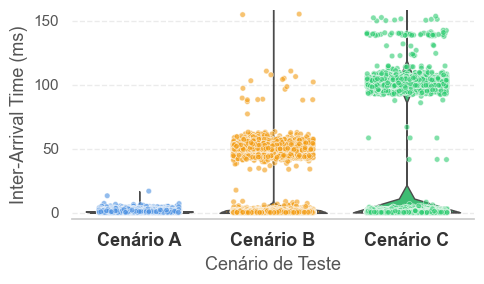

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

# =========================================================================
# 1. CARREGAMENTO DOS DADOS (Com novos nomes e filtro de Jitter real)
# =========================================================================
def carregar_dados():
    base_path = '../dados_e_logs/processados/'
    
    # Nomes corretos dos arquivos separados de R-UDP
    files = {
        'A': 'cenarioA_rudp.csv', 
        'B': 'cenarioB_rudp.csv', 
        'C': 'cenarioC_rudp.csv'
    }
    
    dfs = []
    for cenario, file in files.items():
        path = os.path.join(base_path, file)
        if os.path.exists(path):
            df = pd.read_csv(path)
            
            # Filtrar apenas os pacotes de DADOS (ignorar ACKs de resposta pequenos)
            # Isso garante que estamos medindo o Jitter real do fluxo de transferência
            df = df[df['tamanho_pacote'] > 1000].copy()
            
            df['Cenario'] = f'Cenário {cenario}'
            dfs.append(df)
        else:
            print(f"ERRO: Arquivo não encontrado: {path}")
            
    if not dfs:
        print("Nenhum dado foi carregado. Verifique o caminho base_path.")
        return None
    return pd.concat(dfs, ignore_index=True)

df_real = carregar_dados()

if df_real is not None:
    # ---------------------------------------------------------------------
    # CÁLCULO DO JITTER (Tempo entre chegadas)
    # ---------------------------------------------------------------------
    # Ordenar por cenário e timestamp antes do cálculo diferencial
    df_real = df_real.sort_values(by=['Cenario', 'timestamp'])
    
    # Calcula o Inter-Arrival Time apenas para a direção de transmissão
    df_real['inter_arrival_ms'] = df_real.groupby('Cenario')['timestamp'].diff() * 1000

# =========================================================================
# 2. GERAÇÃO DO GRÁFICO PREMIUM (Violino + Stripplot)
# =========================================================================
if df_real is not None:
    sns.set_theme(style="whitegrid", rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.spines.left": False, 
        "grid.color": "#ebebeb",
        "grid.linestyle": "--"
    })
    
    plt.figure(figsize=(5,3)) 
    cores = ["#4A90E2", "#F39C12", "#2ECC71"]
    
    # 2. O Violão (Escala real) - Correção aplicada com subset
    sns.violinplot(
        data=df_real.dropna(subset=['inter_arrival_ms']), 
        x='Cenario', 
        y='inter_arrival_ms', 
        palette=cores,
        hue='Cenario',
        legend=False,
        inner='quartile', 
        cut=0,
        linewidth=1,
        saturation=0.8
    )
    
    # 3. Os Pontos (Stripplot) - Correção aplicada com subset
    sns.stripplot(
        data=df_real.dropna(subset=['inter_arrival_ms']), 
        x='Cenario', 
        y='inter_arrival_ms', 
        palette=cores,
        hue='Cenario',
        legend=False,
        size=4,          
        alpha=0.6,         
        jitter=0.3,       
        linewidth=0.5,
        edgecolor="white" 
    )
    
    # Limite Inteligente: Corta picos extremos para a bolha do violão ficar visível
    max_util = df_real['inter_arrival_ms'].quantile(0.99) # Pega 99% dos dados
    plt.ylim(-5, max_util * 1.5)
    
    # Textos e Tipografia
    # plt.title('Distribuição de Jitter (Atraso entre pacotes) por Cenário (R-UDP)', fontsize=18, fontweight='bold', pad=20, color='#333333')
    plt.ylabel('Inter-Arrival Time (ms)', fontsize=13, fontweight='500', color='#555555')
    plt.xlabel('Cenário de Teste', fontsize=13, fontweight='500', color='#555555')
    
    plt.xticks(fontsize=13, fontweight='600', color='#333333')
    plt.yticks(fontsize=11, color='#555555')
    
    plt.tight_layout()
    plt.savefig("../relatorio_sbc/figuras/Distribuição de Jitter (Atraso entre pacotes) por Cenário.pdf", dpi=300, bbox_inches='tight')
    plt.show()

### 1. Vazão (Throughput) ao Longo do Tempo (Gráfico de Linha)

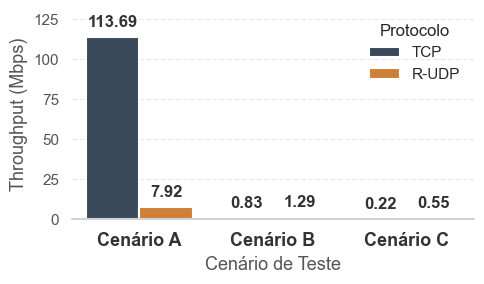

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. PROCESSAMENTO DE DADOS (Arquivos Separados)
# =========================================================================
base_path = "../dados_e_logs/processados/"

def calcular_throughput(caminho_csv):
    """Lê um CSV e calcula o Throughput em Mbps."""
    if not os.path.exists(caminho_csv):
        print(f"Aviso: Arquivo {caminho_csv} não encontrado.")
        return 0.0
        
    df = pd.read_csv(caminho_csv)
    
    if df.empty:
        return 0.0
        
    # Soma de todos os bytes transferidos no arquivo
    total_bytes = df['tamanho_pacote'].sum()
    
    # Tempo total entre o primeiro e o último pacote
    tempo_total_segundos = df['timestamp'].max() - df['timestamp'].min()
    
    if tempo_total_segundos == 0:
        return 0.0
        
    # Cálculo: (Bytes * 8 = Bits) / Segundos / 1.000.000 = Mbps
    throughput_mbps = (total_bytes * 8) / (tempo_total_segundos * 1_000_000)
    
    return throughput_mbps

dados = []
cenarios = ['A', 'B', 'C']

# Loop para processar e extrair as métricas de todos os cenários e protocolos
for cenario in cenarios:
    # Definindo os caminhos corretos conforme o novo padrão de nomes
    csv_rudp = f"{base_path}cenario{cenario}_rudp.csv"
    csv_tcp = f"{base_path}cenario{cenario}_tcp.csv"
    
    # Calculando
    vazao_rudp = calcular_throughput(csv_rudp)
    vazao_tcp = calcular_throughput(csv_tcp)
    
    # Adicionando na lista para o gráfico (A ordem aqui importa para as barras)
    dados.append({'Cenario': f"Cenário {cenario}", 'Protocolo': 'TCP', 'Throughput_Mbps': vazao_tcp})
    dados.append({'Cenario': f"Cenário {cenario}", 'Protocolo': 'R-UDP', 'Throughput_Mbps': vazao_rudp})

# Convertendo para o formato DataFrame do Pandas
df_throughput = pd.DataFrame(dados)

# =========================================================================
# 2. GERAÇÃO DO GRÁFICO PREMIUM (Barras Agrupadas)
# =========================================================================
# Removendo as bordas pesadas e suavizando o fundo
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

plt.figure(figsize=(5, 3))

# Paleta de cores com alto contraste e elegância
cores_protocolo = {"TCP": "#34495E", "R-UDP": "#E67E22"}

# Criando o gráfico
ax = sns.barplot(
    data=df_throughput, 
    x='Cenario', 
    y='Throughput_Mbps', 
    hue='Protocolo',
    palette=cores_protocolo,
    edgecolor="white",
    linewidth=1.5
)

# Adicionando os números exatos sobre cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0: 
        ax.annotate(f'{altura:.2f}', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    fontsize=12, fontweight='bold', color='#333333', 
                    xytext=(0, 5), textcoords='offset points')

# Estilização de Títulos e Eixos
# plt.title('Comparativo de Vazão (Throughput) Média: TCP vs R-UDP', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.ylabel('Throughput (Mbps)', fontsize=13, fontweight='500', color='#555555')
plt.xlabel('Cenário de Teste', fontsize=13, fontweight='500', color='#555555')

plt.xticks(fontsize=13, fontweight='600', color='#333333')
plt.yticks(fontsize=11, color='#555555')

plt.legend(title='Protocolo', title_fontsize='12', fontsize='11', frameon=False, loc='upper right')

# Respiro de 15% acima da barra mais alta para evitar que os números cortem
max_val = df_throughput['Throughput_Mbps'].max()
plt.ylim(0, max_val * 1.15 if max_val > 0 else 10)

plt.tight_layout()
plt.savefig("../relatorio_sbc/figuras/Comparativo de Vazão (Throughput) Média - TCP vs R-UDP.pdf", dpi=300, bbox_inches='tight')
plt.show()

Esse é o gráfico mais importante para mostrar a eficiência bruta da transferência. Ele vai responder: *"Quem conseguiu transferir os dados mais rápido e de forma mais estável?"*

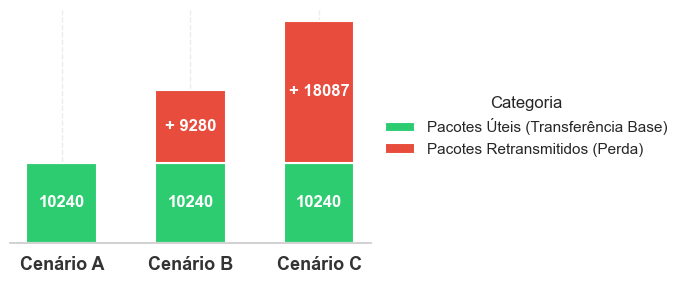

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. PROCESSAMENTO DE DADOS (R-UDP)
# =========================================================================
base_path = "../dados_e_logs/processados/"
cenarios = ['A', 'B', 'C']

# Arquivo de 10 MB = 10.485.760 bytes
# Dividido por 1024 bytes de payload útil por pacote = exatos 10.240 pacotes
PACOTES_UTEIS_ESPERADOS = 10240 

dados = []

for cenario in cenarios:
    caminho = f"{base_path}cenario{cenario}_rudp.csv"
    
    if os.path.exists(caminho):
        df = pd.read_csv(caminho)
        
        # Filtramos APENAS os pacotes de dados (tamanho > 1000 bytes)
        # Isso ignora os pequenos pacotes de ACK (que têm cerca de 106 bytes)
        df_dados = df[df['tamanho_pacote'] > 1000]
        
        total_enviados = len(df_dados)
        
        # O que passou de 10.240 é retransmissão
        retransmitidos = total_enviados - PACOTES_UTEIS_ESPERADOS
        if retransmitidos < 0:
            retransmitidos = 0 
            
        dados.append({
            'Cenario': f'Cenário {cenario}',
            'Úteis': PACOTES_UTEIS_ESPERADOS,
            'Retransmitidos': retransmitidos
        })

df_plot = pd.DataFrame(dados)

# =========================================================================
# 2. GERAÇÃO DO GRÁFICO EMPILHADO (Stacked Bar)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

fig, ax = plt.subplots(figsize=(7, 3))

bar_width = 0.55
x_pos = range(len(df_plot['Cenario']))

# 1ª Camada (Base): Pacotes Úteis (Verde)
bars_uteis = ax.bar(x_pos, df_plot['Úteis'], bar_width, 
                    label='Pacotes Úteis (Transferência Base)', 
                    color='#2ECC71', edgecolor='white', linewidth=1.5)

# 2ª Camada (Topo): Retransmissões (Vermelho)
bars_retrans = ax.bar(x_pos, df_plot['Retransmitidos'], bar_width, 
                      bottom=df_plot['Úteis'], 
                      label='Pacotes Retransmitidos (Perda)', 
                      color='#E74C3C', edgecolor='white', linewidth=1.5)

# Adicionando os valores em texto DENTRO das barras
for idx, (util, retrans) in enumerate(zip(df_plot['Úteis'], df_plot['Retransmitidos'])):
    # Texto dos Úteis (no meio da barra verde)
    ax.text(idx, util / 2, f'{int(util)}', 
            ha='center', va='center', color='white', fontweight='bold', fontsize=12)
    
    # Texto das Retransmissões (no meio da barra vermelha)
    if retrans > 0:
        ax.text(idx, util + (retrans / 2), f'+ {int(retrans)}', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=12)

# Estilização
ax.set_xticks(x_pos)
ax.set_xticklabels(df_plot['Cenario'], fontsize=13, fontweight='600', color='#333333')

# Removemos os números gigantes do eixo Y para um design mais limpo
ax.set_yticks([]) 

# ax.set_title('Impacto da Perda: Pacotes Úteis vs Retransmissões (R-UDP)', fontsize=16, fontweight='bold', pad=20, color='#333333')

# Ajuste da legenda para ficar fora da área do gráfico e não cobrir a barra
ax.legend(title='Categoria', title_fontsize='12', fontsize='11', 
          loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)

plt.tight_layout()
plt.savefig("../relatorio_sbc/figuras/Impacto da Perda - Pacotes Úteis vs Retransmissões (R-UDP).pdf", dpi=300, bbox_inches='tight')
plt.show()

### 2. Gráfico de Tempo-Sequência (Gráfico de Stevens)

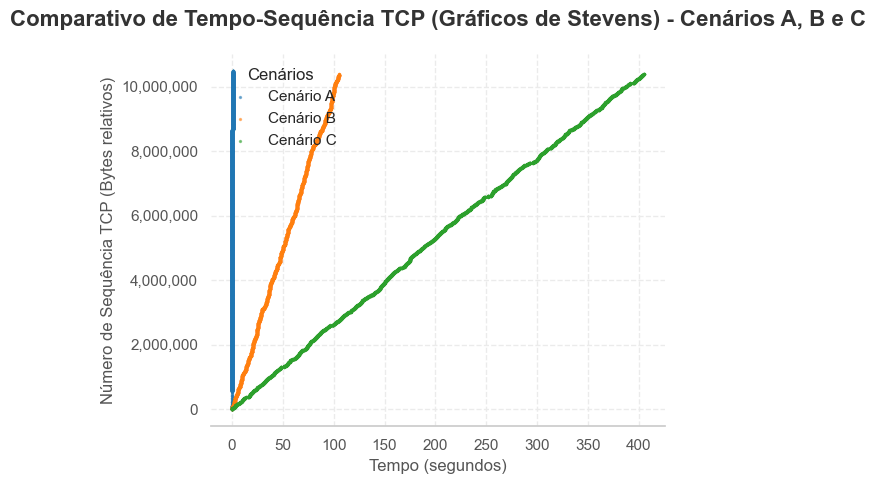

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configurações estéticas do Seaborn
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

plt.figure(figsize=(6,5))

# Cores distintas para diferenciar visualmente cada cenário
cores = {
    'A': '#1F77B4',  # Azul (Sem perdas/latência)
    'B': '#FF7F0E',  # Laranja (Latência + Perda leve)
    'C': '#2CA02C'   # Verde (Perda severa 20%)
}

base_path = os.path.join('../dados_e_logs', 'processados')
cenarios = {
    'A': 'cenarioA_tcp.csv', 
    'B': 'cenarioB_tcp.csv', 
    'C': 'cenarioC_tcp.csv'
}

for cenario, nome_arquivo in cenarios.items():
    caminho = os.path.join(base_path, nome_arquivo)
    if not os.path.exists(caminho):
        print(f"Aviso: Arquivo {caminho} não encontrado. Pulando...")
        continue
        
    # 1. Carregamento e remoção de valores nulos de sequência
    df = pd.read_csv(caminho)
    df = df.dropna(subset=['numero_sequencia_tcp'])
    
    if df.empty:
        continue
        
    # 2. Identificação automática do fluxo principal de dados (envio)
    fluxos = df.groupby(['ip_origem', 'porta_origem'])['tamanho_pacote'].sum().reset_index()
    fluxo_principal = fluxos.sort_values(by='tamanho_pacote', ascending=False).iloc[0]
    
    ip_remetente = fluxo_principal['ip_origem']
    porta_remetente = fluxo_principal['porta_origem']
    
    # Filtra mantendo apenas o fluxo do remetente
    df_fluxo = df[(df['ip_origem'] == ip_remetente) & (df['porta_origem'] == porta_remetente)].copy()
    
    # 3. Normalização individual por cenário
    t_min = df_fluxo['timestamp'].min()
    seq_min = df_fluxo['numero_sequencia_tcp'].min()
    
    df_fluxo['tempo_relativo'] = df_fluxo['timestamp'] - t_min
    df_fluxo['seq_relativo'] = df_fluxo['numero_sequencia_tcp'] - seq_min
    
    # 4. Plotagem dos dados do cenário atual
    plt.scatter(
        df_fluxo['tempo_relativo'], 
        df_fluxo['seq_relativo'], 
        color=cores[cenario],
        marker='.', 
        s=8, 
        alpha=0.5,
        label=f'Cenário {cenario}'
    )

# Configurações visuais finais
plt.title('Comparativo de Tempo-Sequência TCP (Gráficos de Stevens) - Cenários A, B e C', fontsize=16, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Tempo (segundos)', fontsize=12, fontweight='500', color='#555555')
plt.ylabel('Número de Sequência TCP (Bytes relativos)', fontsize=12, fontweight='500', color='#555555')

plt.xticks(fontsize=11, color='#555555')
ax = plt.gca()
# Formata o eixo Y com separador de milhar para facilitar a contagem de bytes
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.yticks(fontsize=11, color='#555555')

plt.legend(title='Cenários', frameon=False, fontsize=11, loc='upper left')
plt.tight_layout()

# Salva a imagem na pasta de figuras
pasta_figuras = os.path.join('../relatorio_sbc', 'figuras')
os.makedirs(pasta_figuras, exist_ok=True)
plt.savefig(os.path.join(pasta_figuras, 'comparativo_stevens_tcp.pdf'), dpi=300, bbox_inches='tight')

plt.show()

Esse gráfico é clássico em análise de redes e mostra exatamente como os dados fluem, permitindo ver visualmente onde ocorrem perdas, retransmissões e atrasos.

* **Para o TCP:** Plote um gráfico de dispersão (Scatter plot). Eixo X = `timestamp` (subtraindo o timestamp do primeiro pacote para começar em 0) e Eixo Y = `numero_sequencia_tcp`.
* **O que ele mostra:** Uma linha reta e inclinada significa uma transferência perfeita. Degraus ou pontos "voltando" no eixo Y indicam retransmissões.
* **Para o R-UDP:** Como os dados da rede marcam isso como UDP, a ferramenta de captura não lê nativamente o número de sequência do seu R-UDP. Se o seu R-UDP colocou o número de sequência no payload e não aparece no CSV, não tem problema focar esse gráfico apenas no TCP ou plotar os pacotes R-UDP apenas pela ordem de chegada.

### 3. Dinâmica da Janela de Recepção TCP (Gráfico de Linha)

Aviso: IP_RECEPTOR '172.24.0.2' não gerou pacotes no Cenário A. Usando automaticamente o provável IP do receptor: '172.18.0.3'
Aviso: IP_RECEPTOR '172.24.0.2' não gerou pacotes no Cenário B. Usando automaticamente o provável IP do receptor: '172.18.0.3'
Aviso: IP_RECEPTOR '172.24.0.2' não gerou pacotes no Cenário C. Usando automaticamente o provável IP do receptor: '172.18.0.3'


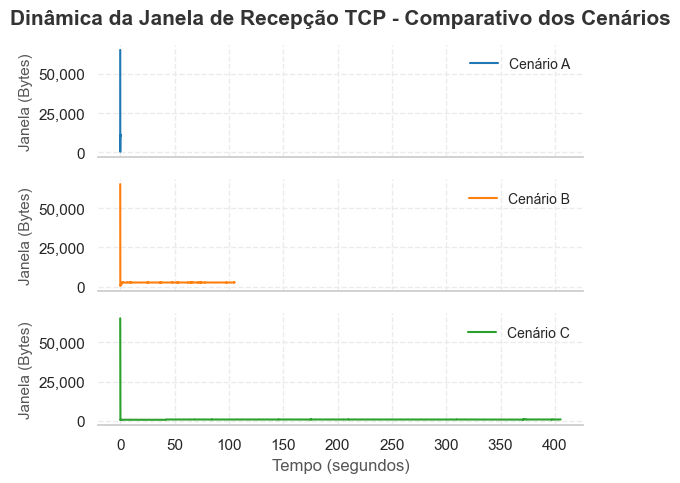

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# CONFIGURAÇÃO DE PARÂMETROS
# =========================================================================
# IP do receptor de dados TCP (quem envia os ACKs de volta informando o tamanho da janela de recepção)
IP_RECEPTOR = '172.24.0.2'  # Altere para o IP do seu receptor de dados TCP

# Caminho dos arquivos
base_path = '../dados_e_logs/processados/'
arquivos = {
    'A': 'cenarioA_tcp.csv',
    'B': 'cenarioB_tcp.csv',
    'C': 'cenarioC_tcp.csv'
}

# Cores distintas
cores = {
    'A': '#1F77B4',  # Azul
    'B': '#FF7F0E',  # Laranja
    'C': '#2CA02C'   # Verde
}

# =========================================================================
# 1. CARREGAMENTO E PROCESSAMENTO DOS DADOS
# =========================================================================
dfs_processados = {}

for cenario, nome_arquivo in arquivos.items():
    caminho = os.path.join(base_path, nome_arquivo)
    if not os.path.exists(caminho):
        # Fallback caso esteja rodando fora da estrutura padrão de pastas
        caminho_local = os.path.join('dados_e_logs', 'processados', nome_arquivo)
        if os.path.exists(caminho_local):
            caminho = caminho_local
        else:
            print(f"Aviso: Arquivo {nome_arquivo} não encontrado. Pulando...")
            continue
            
    df = pd.read_csv(caminho)
    
    # Remove qualquer linha onde a janela TCP seja nula
    df = df.dropna(subset=['tamanho_janela_tcp'])
    
    # Filtra para obter apenas os pacotes gerados pelo receptor (fluxo de ACKs)
    df_ack = df[df['ip_origem'] == IP_RECEPTOR].copy()
    
    # Detecção automática alternativa se o IP_RECEPTOR não bater
    if df_ack.empty:
        fluxos = df.groupby(['ip_origem', 'porta_origem']).size().reset_index(name='count')
        if len(fluxos) > 1:
            # Em fluxos de transferência massiva de dados, a máquina que envia menos pacotes 
            # é o receptor que apenas retorna ACKs / atualizações de controle de fluxo
            ip_provavel = fluxos.sort_values(by='count').iloc[0]['ip_origem']
            df_ack = df[df['ip_origem'] == ip_provavel].copy()
            print(f"Aviso: IP_RECEPTOR '{IP_RECEPTOR}' não gerou pacotes no Cenário {cenario}. "
                  f"Usando automaticamente o provável IP do receptor: '{ip_provavel}'")
        else:
            print(f"Erro: Não foi possível discernir o fluxo de ACKs para o Cenário {cenario}.")
            continue
            
    # Normalização temporal (Tempo relativo iniciando em 0.0s)
    tempo_min = df_ack['timestamp'].min()
    df_ack['tempo_relativo'] = df_ack['timestamp'] - tempo_min
    
    dfs_processados[cenario] = df_ack

# =========================================================================
# 2. GERAÇÃO DO GRÁFICO (Gráficos Alinhados ou Único)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

# Altere para False caso queira plotar as 3 curvas sobrepostas em um único gráfico
usar_subplots = True

if usar_subplots:
    # Layout Alinhado Verticalmente (Recomendado para visualização comparativa limpa)
    fig, axes = plt.subplots(3, 1, figsize=(6,5), sharex=True)
    
    for idx, (cenario, df_plot) in enumerate(dfs_processados.items()):
        ax = axes[idx]
        ax.plot(
            df_plot['tempo_relativo'], 
            df_plot['tamanho_janela_tcp'], 
            color=cores[cenario],
            linewidth=1.5,
            label=f'Cenário {cenario}'
        )
        ax.set_ylabel('Janela (Bytes)', fontsize=11, color='#555555')
        ax.legend(loc='upper right', frameon=False, fontsize=10)
        # Formata o eixo Y com separadores de milhar
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
        
    axes[0].set_title('Dinâmica da Janela de Recepção TCP - Comparativo dos Cenários', fontsize=15, fontweight='bold', pad=15, color='#333333')
    axes[2].set_xlabel('Tempo (segundos)', fontsize=12, color='#555555')
    
    plt.tight_layout()
    # Cria pasta de figuras se não existir e salva
    os.makedirs('../relatorio_sbc/figuras', exist_ok=True)
    plt.savefig('../relatorio_sbc/figuras/dinamica_janela_recepcao_tcp_subplots.pdf', dpi=300, bbox_inches='tight')
else:
    # Layout Único com Linhas Sobrepostas
    plt.figure(figsize=(6,5))
    
    for cenario, df_plot in dfs_processados.items():
        plt.plot(
            df_plot['tempo_relativo'], 
            df_plot['tamanho_janela_tcp'], 
            color=cores[cenario],
            linewidth=1.2,
            alpha=0.8,
            label=f'Cenário {cenario}'
        )
        
    plt.title('Dinâmica da Janela de Recepção TCP - Comparativo dos Cenários', fontsize=16, fontweight='bold', pad=20, color='#333333')
    plt.xlabel('Tempo (segundos)', fontsize=12, color='#555555')
    plt.ylabel('Tamanho da Janela TCP (Bytes)', fontsize=12, color='#555555')
    
    ax = plt.gca()
    ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
    
    plt.legend(title='Cenários', frameon=False, fontsize=11, loc='upper right')
    plt.tight_layout()
    
    os.makedirs('../relatorio_sbc/figuras', exist_ok=True)
    plt.savefig('../relatorio_sbc/figuras/dinamica_janela_recepcao_tcp_single.pdf', dpi=300, bbox_inches='tight')

plt.show()

Como seu trabalho fala sobre janelas deslizantes (Go-Back-N ou Selective Repeat), é muito interessante mostrar como o TCP lida com o controle de fluxo na prática.

* **Como fazer:** Use apenas o arquivo `cenarioX_tcp.csv`. Coloque no eixo X o `timestamp` e no eixo Y o `tamanho_janela_tcp`.
* **O que ele mostra:** Ele evidenciará o comportamento do mecanismo de Controle de Fluxo/Congestionamento do TCP se adaptando à rede.

### 4. Distribuição do Tamanho dos Pacotes / Overhead (Gráfico de Barras ou Histograma)

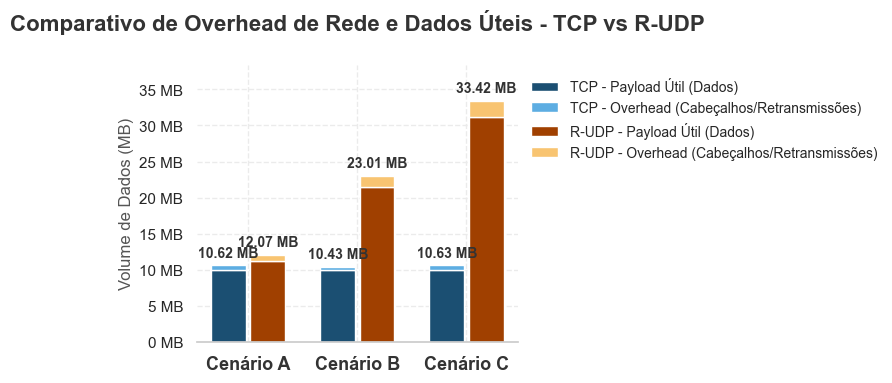

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CARREGAMENTO E PROCESSAMENTO DOS DADOS (6 Arquivos)
# =========================================================================
base_path = '../dados_e_logs/processados/'
cenarios = ['A', 'B', 'C']
protocolos = ['tcp', 'rudp']

# Dicionário para armazenar os resultados
metricas = {
    'A': {'tcp': {'payload': 0, 'overhead': 0}, 'rudp': {'payload': 0, 'overhead': 0}},
    'B': {'tcp': {'payload': 0, 'overhead': 0}, 'rudp': {'payload': 0, 'overhead': 0}},
    'C': {'tcp': {'payload': 0, 'overhead': 0}, 'rudp': {'payload': 0, 'overhead': 0}}
}

for cenario in cenarios:
    for proto in protocolos:
        nome_arquivo = f"cenario{cenario}_{proto}.csv"
        caminho = os.path.join(base_path, nome_arquivo)
        
        # Fallback local se estiver rodando fora da árvore padrão de pastas
        if not os.path.exists(caminho):
            caminho_local = os.path.join('dados_e_logs', 'processados', nome_arquivo)
            if os.path.exists(caminho_local):
                caminho = caminho_local
            else:
                print(f"Aviso: Arquivo {nome_arquivo} não encontrado. Pulando...")
                continue
        
        df = pd.read_csv(caminho)
        
        # Filtragem preventiva de campos nulos
        df = df.dropna(subset=['tamanho_pacote', 'tamanho_payload'])
        
        # Soma total em Bytes
        total_pacote = df['tamanho_pacote'].sum()
        total_payload = df['tamanho_payload'].sum()
        total_overhead = total_pacote - total_payload
        
        # Conversão para Megabytes (MB)
        # 1 MB = 1024 * 1024 Bytes
        payload_mb = total_payload / (1024 * 1024)
        overhead_mb = total_overhead / (1024 * 1024)
        
        metricas[cenario][proto]['payload'] = payload_mb
        metricas[cenario][proto]['overhead'] = overhead_mb

# Preparação das listas para plotagem
tcp_payload = [metricas[c]['tcp']['payload'] for c in cenarios]
tcp_overhead = [metricas[c]['tcp']['overhead'] for c in cenarios]

rudp_payload = [metricas[c]['rudp']['payload'] for c in cenarios]
rudp_overhead = [metricas[c]['rudp']['overhead'] for c in cenarios]

# =========================================================================
# 2. GERAÇÃO DO GRÁFICO DE BARRAS EMPILHADAS E AGRUPADAS (Stacked & Grouped)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

fig, ax = plt.subplots(figsize=(8, 4))

# Configuração das posições no eixo X
x_pos = np.arange(len(cenarios))
width = 0.32  # Largura das barras individuais

# Paleta de Cores Premium (Contraste entre Útil e Overhead para TCP e R-UDP)
colors = {
    'tcp_payload': '#1B4F72',     # Azul Marinho Escuro
    'tcp_overhead': '#5DADE2',    # Azul Claro
    'rudp_payload': '#A04000',    # Laranja Queimado / Escuro
    'rudp_overhead': '#F8C471'    # Laranja Claro / Pêssego
}

# 1. Plotagem das barras de TCP (Esquerda de cada cenário)
bars_tcp_pay = ax.bar(x_pos - width/2 - 0.02, tcp_payload, width, 
                      label='TCP - Payload Útil (Dados)', 
                      color=colors['tcp_payload'], edgecolor='white', linewidth=1)

bars_tcp_over = ax.bar(x_pos - width/2 - 0.02, tcp_overhead, width, 
                       bottom=tcp_payload, 
                       label='TCP - Overhead (Cabeçalhos/Retransmissões)', 
                       color=colors['tcp_overhead'], edgecolor='white', linewidth=1)

# 2. Plotagem das barras de R-UDP (Direita de cada cenário)
bars_rudp_pay = ax.bar(x_pos + width/2 + 0.02, rudp_payload, width, 
                       label='R-UDP - Payload Útil (Dados)', 
                       color=colors['rudp_payload'], edgecolor='white', linewidth=1)

bars_rudp_over = ax.bar(x_pos + width/2 + 0.02, rudp_overhead, width, 
                        bottom=rudp_payload, 
                        label='R-UDP - Overhead (Cabeçalhos/Retransmissões)', 
                        color=colors['rudp_overhead'], edgecolor='white', linewidth=1)

# 3. Adição dos rótulos numéricos (Valores totais acima de cada barra)
for i in range(len(cenarios)):
    # Total de dados transmitidos pelo TCP no cenário i
    total_tcp = tcp_payload[i] + tcp_overhead[i]
    if total_tcp > 0:
        ax.annotate(f'{total_tcp:.2f} MB',
                    xy=(x_pos[i] - width/2 - 0.02, total_tcp),
                    xytext=(0, 4), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')
        
    # Total de dados transmitidos pelo R-UDP no cenário i
    total_rudp = rudp_payload[i] + rudp_overhead[i]
    if total_rudp > 0:
        ax.annotate(f'{total_rudp:.2f} MB',
                    xy=(x_pos[i] + width/2 + 0.02, total_rudp),
                    xytext=(0, 4), 
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold', color='#333333')

# Estilização de Eixos e Títulos
ax.set_xticks(x_pos)
ax.set_xticklabels([f"Cenário {c}" for c in cenarios], fontsize=13, fontweight='600', color='#333333')
ax.set_ylabel('Volume de Dados (MB)', fontsize=12, fontweight='500', color='#555555')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)} MB"))

plt.title('Comparativo de Overhead de Rede e Dados Úteis - TCP vs R-UDP', fontsize=16, fontweight='bold', pad=25, color='#333333')

# Posicionamento inteligente da legenda fora da área de plotagem para evitar sobreposição
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=10)

# Respiro de 15% acima do maior valor para evitar corte dos textos informativos
max_valor = max(max(tcp_payload[i] + tcp_overhead[i] for i in range(3)), 
                max(rudp_payload[i] + rudp_overhead[i] for i in range(3)))
plt.ylim(0, max_valor * 1.15)

plt.tight_layout()

# Salvar figura de alta qualidade
os.makedirs('../relatorio_sbc/figuras', exist_ok=True)
plt.savefig('../relatorio_sbc/figuras/comparativo_overhead_payload_tcp_rudp.pdf', dpi=300, bbox_inches='tight')

plt.show()

A ideia aqui é comparar o quanto de "esforço" de rede foi gasto com dados úteis x controle.


### 5. Pacotes de Dados vs. Pacotes de Controle (Gráfico de Pizza ou Barras Empilhadas)

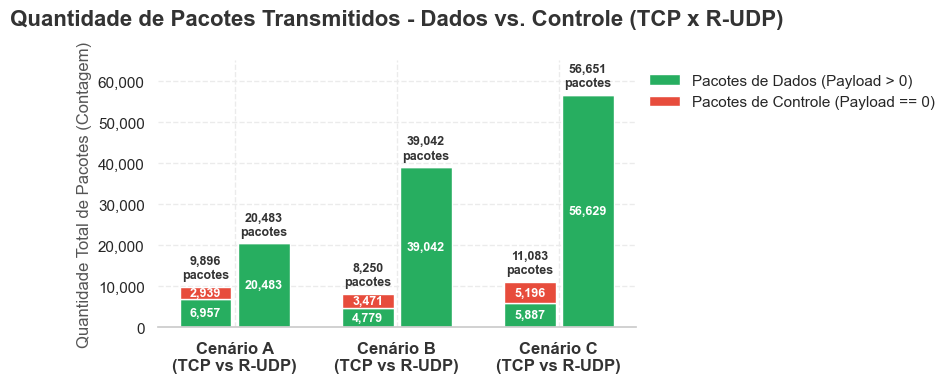

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CARREGAMENTO E CONSOLIDAÇÃO DOS DADOS (6 Arquivos)
# =========================================================================
base_path = '../dados_e_logs/processados/'
cenarios = ['A', 'B', 'C']
protocolos = {'tcp': 'TCP', 'rudp': 'R-UDP'}

dfs = []
for cenario in cenarios:
    for proto_file, proto_label in protocolos.items():
        nome_arquivo = f"cenario{cenario}_{proto_file}.csv"
        caminho = os.path.join(base_path, nome_arquivo)
        
        # Fallback local se estiver rodando fora da árvore padrão de pastas
        if not os.path.exists(caminho):
            caminho_local = os.path.join('dados_e_logs', 'processados', nome_arquivo)
            if os.path.exists(caminho_local):
                caminho = caminho_local
            else:
                print(f"Aviso: Arquivo {nome_arquivo} não encontrado. Pulando...")
                continue
        
        df_temp = pd.read_csv(caminho)
        df_temp['Cenario'] = f"Cenário {cenario}"
        df_temp['Protocolo'] = proto_label
        dfs.append(df_temp[['tamanho_payload', 'Cenario', 'Protocolo']])

# Consolida todos em um único DataFrame
df_all = pd.concat(dfs, ignore_index=True)

# 2. CLASSIFICAÇÃO LÓGICA DO TIPO DE PACOTE
# Payload > 0 representam dados úteis de aplicação, payload == 0 são controle (ACK, SYN, etc.)
df_all['tipo_pacote'] = np.where(df_all['tamanho_payload'] > 0, 'Dados', 'Controle')

# Agrupamento e contagem por cenário, protocolo e tipo de pacote
contagem = df_all.groupby(['Cenario', 'Protocolo', 'tipo_pacote']).size().unstack(fill_value=0).reset_index()

# Separação dos dados para plotagem
tcp_dados = []
tcp_controle = []
rudp_dados = []
rudp_controle = []

for c in [f"Cenário {cen}" for cen in cenarios]:
    row_tcp = contagem[(contagem['Cenario'] == c) & (contagem['Protocolo'] == 'TCP')]
    row_rudp = contagem[(contagem['Cenario'] == c) & (contagem['Protocolo'] == 'R-UDP')]
    
    tcp_dados.append(row_tcp['Dados'].values[0] if not row_tcp.empty else 0)
    tcp_controle.append(row_tcp['Controle'].values[0] if not row_tcp.empty else 0)
    
    rudp_dados.append(row_rudp['Dados'].values[0] if not row_rudp.empty else 0)
    rudp_controle.append(row_rudp['Controle'].values[0] if not row_rudp.empty else 0)

# =========================================================================
# 2. GERAÇÃO DO GRÁFICO DE BARRAS EMPILHADAS (Stacked & Grouped)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

fig, ax = plt.subplots(figsize=(9,4))

x_pos = np.arange(len(cenarios))
width = 0.32  # Largura de cada barra agrupada

# Cores clássicas para Dados (Verde) e Controle (Vermelho/Cinza)
colors = {
    'dados': '#27AE60',      # Verde Médio
    'controle': '#E74C3C'    # Vermelho Suave
}

# 1. Plotagem das barras de TCP (Esquerda)
bars_tcp_data = ax.bar(x_pos - width/2 - 0.02, tcp_dados, width, 
                       label='Pacotes de Dados (Payload > 0)', 
                       color=colors['dados'], edgecolor='white', linewidth=1)

bars_tcp_ctrl = ax.bar(x_pos - width/2 - 0.02, tcp_controle, width, 
                       bottom=tcp_dados, 
                       label='Pacotes de Controle (Payload == 0)', 
                       color=colors['controle'], edgecolor='white', linewidth=1)

# 2. Plotagem das barras de R-UDP (Direita)
bars_rudp_data = ax.bar(x_pos + width/2 + 0.02, rudp_dados, width, 
                        color=colors['dados'], edgecolor='white', linewidth=1)

bars_rudp_ctrl = ax.bar(x_pos + width/2 + 0.02, rudp_controle, width, 
                        bottom=rudp_dados, 
                        color=colors['controle'], edgecolor='white', linewidth=1)

# 3. Adição de Rótulos de Texto Internos
# Adiciona o número de pacotes centralizado em cada pilha, se houver espaço mínimo
def rotular_pilhas(bars, dados, controles):
    for rect, d_val, c_val in zip(bars, dados, controles):
        # Rótulo da parte de Dados (base)
        if d_val > 800:
            ax.text(rect.get_x() + rect.get_width()/2., d_val / 2, f"{d_val:,}", 
                    ha='center', va='center', color='white', fontweight='bold', fontsize=9)
        # Rótulo da parte de Controle (topo)
        if c_val > 800:
            ax.text(rect.get_x() + rect.get_width()/2., d_val + (c_val / 2), f"{c_val:,}", 
                    ha='center', va='center', color='white', fontweight='bold', fontsize=9)

rotular_pilhas(bars_tcp_data, tcp_dados, tcp_controle)
rotular_pilhas(bars_rudp_data, rudp_dados, rudp_controle)

# Adição dos rótulos de totais acima de cada barra
for i in range(len(cenarios)):
    total_tcp = tcp_dados[i] + tcp_controle[i]
    total_rudp = rudp_dados[i] + rudp_controle[i]
    
    if total_tcp > 0:
        ax.annotate(f'{total_tcp:,}\npacotes', xy=(x_pos[i] - width/2 - 0.02, total_tcp),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')
    if total_rudp > 0:
        ax.annotate(f'{total_rudp:,}\npacotes', xy=(x_pos[i] + width/2 + 0.02, total_rudp),
                    xytext=(0, 4), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold', color='#333333')

# Identificação clara dos protocolos no eixo X
labels_eixo_x = []
for c in cenarios:
    labels_eixo_x.append(f"Cenário {c}\n(TCP vs R-UDP)")

ax.set_xticks(x_pos)
ax.set_xticklabels(labels_eixo_x, fontsize=12, fontweight='600', color='#333333')
ax.set_ylabel('Quantidade Total de Pacotes (Contagem)', fontsize=12, color='#555555')

# Formatação do eixo Y para contagem comum com separador de milhar (sem notação científica)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))

plt.title('Quantidade de Pacotes Transmitidos - Dados vs. Controle (TCP x R-UDP)', fontsize=16, fontweight='bold', pad=25, color='#333333')

# Legenda baseada nas categorias de pacotes
plt.legend(handles=[bars_tcp_data, bars_tcp_ctrl], labels=['Pacotes de Dados (Payload > 0)', 'Pacotes de Controle (Payload == 0)'],
           loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=11)

# Ajuste do limite superior do eixo Y para acomodar as anotações textuais
max_total = max(max(tcp_dados[i] + tcp_controle[i] for i in range(3)), 
                max(rudp_dados[i] + rudp_controle[i] for i in range(3)))
plt.ylim(0, max_total * 1.15)

plt.tight_layout()

# Salva a figura na pasta relatorio_sbc/figuras
os.makedirs('../relatorio_sbc/figuras', exist_ok=True)
plt.savefig('../relatorio_sbc/figuras/comparativo_contagem_dados_controle.pdf', dpi=300, bbox_inches='tight')

plt.show()

## Fase 02

### 2. A "Teimosia" vs. A "Educação": Média de Retransmissões (Gráfico de Barras Agrupadas)

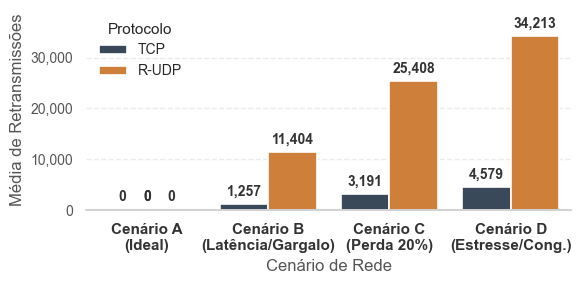

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CONFIGURAÇÕES VISUAIS (Estilo Premium)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

# =========================================================================
# 2. CARREGAMENTO E MAPEAMENTO DOS DADOS
# =========================================================================
caminho_csv = '../dados_e_logs/processados/simulacao_resumo.csv'
# Fallback caso o script seja executado a partir do diretório raiz
if not os.path.exists(caminho_csv):
    caminho_csv = 'dados_e_logs/processados/simulacao_resumo.csv'

df = pd.read_csv(caminho_csv)

# Mapeamento amigável dos cenários para exibição no eixo X
mapeamento_cenarios = {
    'A': 'Cenário A\n(Ideal)',
    'B': 'Cenário B\n(Latência/Gargalo)',
    'C': 'Cenário C\n(Perda 20%)',
    'D_estresse': 'Cenário D\n(Estresse/Cong.)'
}
df['cenario_formatado'] = df['cenario'].map(mapeamento_cenarios)

ordem_cenarios = [
    'Cenário A\n(Ideal)',
    'Cenário B\n(Latência/Gargalo)',
    'Cenário C\n(Perda 20%)',
    'Cenário D\n(Estresse/Cong.)'
]

# Paleta de cores consistente com os demais gráficos do projeto
cores_protocolo = {"TCP": "#34495E", "R-UDP": "#E67E22"}

# =========================================================================
# 3. CONSTRUÇÃO DO PLOT DE BARRAS AGRUPADAS
# =========================================================================
plt.figure(figsize=(6,3))

# O sns.barplot calcula automaticamente a média quando há múltiplas execuções por cenário
ax = sns.barplot(
    data=df,
    x="cenario_formatado",
    y="total_retransmissoes",
    hue="protocolo",
    order=ordem_cenarios,
    palette=cores_protocolo,
    edgecolor="white",
    linewidth=1.2,
    errorbar=None  # Oculta barras de erro para manter o gráfico limpo
)

# Adicionar os números exatos sobre cada barra (médias absolutas arredondadas)
for p in ax.patches:
    altura = p.get_height()
    if altura > 10:
        # Se for um valor significativo, exibe o número formatado com separador de milhar
        ax.annotate(f'{int(round(altura)):,}', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', color='#333333', 
                    xytext=(0, 4), textcoords='offset points')
    elif altura == 0 or pd.isna(altura):
        # Se for exatamente zero (Cenário A), exibe '0'
        ax.annotate('0', 
                    (p.get_x() + p.get_width() / 2., 0), 
                    ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', color='#333333', 
                    xytext=(0, 4), textcoords='offset points')

# Estilização de Títulos e Eixos
# plt.title('Impacto da Ausência de Controle de Congestionamento\n(Média de Retransmissões TCP vs R-UDP na Fase 2)', 
#           fontsize=14, fontweight='bold', pad=20, color='#333333')
plt.ylabel('Média de Retransmissões', fontsize=12, fontweight='500', color='#555555')
plt.xlabel('Cenário de Rede', fontsize=12, fontweight='500', color='#555555')

plt.xticks(fontsize=11, fontweight='600', color='#333333')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.yticks(fontsize=10, color='#555555')

plt.legend(title="Protocolo", title_fontsize='11', fontsize='10', frameon=False, loc='upper left')

# Adiciona um respiro de 15% acima da barra mais alta para as anotações não serem cortadas
max_val = df.groupby(['cenario', 'protocolo'])['total_retransmissoes'].mean().max()
plt.ylim(0, max_val * 1.15)

plt.tight_layout()

# Salvar figura (duplo salvamento para funcionar localmente ou a partir de subpastas no Jupyter)
os.makedirs('../relatorio_sbc/figuras', exist_ok=True)
try:
    # plt.savefig('../relatorio_sbc/figuras/barplot_retransmissoes_fase2.png', dpi=300, bbox_inches='tight')
    plt.savefig('../relatorio_sbc/figuras/barplot_retransmissoes_fase2.pdf', dpi=300, bbox_inches='tight')
except Exception:
    os.makedirs('relatorio_sbc/figuras', exist_ok=True)
    # plt.savefig('relatorio_sbc/figuras/barplot_retransmissoes_fase2.png', dpi=300, bbox_inches='tight')
    plt.savefig('relatorio_sbc/figuras/barplot_retransmissoes_fase2.pdf', dpi=300, bbox_inches='tight')

plt.show()

Lembra da nossa conclusão brilhante sobre o TCP fazer 4.600 retransmissões e o R-UDP explodir para mais de 35.000? Isso precisa virar um gráfico de impacto.

## Fase 02 - Tarefas

### 1. Escalabilidade de Vazão por Tamanho de Arquivo (Tarefa 4)

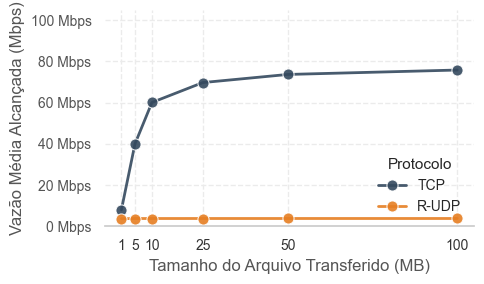

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CONFIGURAÇÕES VISUAIS (Estilo Premium)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

# =========================================================================
# 2. CARREGAMENTO E FILTRAGEM DOS DADOS
# =========================================================================
caminho_csv = '../dados_e_logs/processados/tarefa4_vazao.csv'
# Fallback caso o script seja executado a partir do diretório raiz
if not os.path.exists(caminho_csv):
    caminho_csv = 'dados_e_logs/processados/tarefa4_vazao.csv'

df = pd.read_csv(caminho_csv)

# Filtrar para exibir apenas o Cenário A (Verificação do teto puro de vazão)
df_cenarioA = df[df['cenario'] == 'A'].copy()

# Ordena o DataFrame pelo tamanho do arquivo para garantir a linha contínua correta
df_cenarioA = df_cenarioA.sort_values(by='tamanho_arquivo_mb')

# =========================================================================
# 3. GERAÇÃO DO GRÁFICO DE LINHA COMPARATIVO
# =========================================================================
plt.figure(figsize=(5, 3))

# Paleta de cores consistente
cores_protocolo = {"TCP": "#34495E", "R-UDP": "#E67E22"}

# Plotagem usando o lineplot do Seaborn com marcadores bem visíveis
ax = sns.lineplot(
    data=df_cenarioA, 
    x='tamanho_arquivo_mb', 
    y='vazao_media_mbps', 
    hue='protocolo', 
    palette=cores_protocolo,
    marker='o',
    markersize=8,
    linewidth=2,
    alpha=0.9
)

# Estilização de Eixos e Títulos
# plt.title('Escalabilidade de Vazão por Tamanho de Arquivo\n(Cenário A - Link Ideal de 100 Mbps)', 
#           fontsize=14, fontweight='bold', pad=20, color='#333333')
plt.xlabel('Tamanho do Arquivo Transferido (MB)', fontsize=12, fontweight='500', color='#555555')
plt.ylabel('Vazão Média Alcançada (Mbps)', fontsize=12, fontweight='500', color='#555555')

plt.xticks(df_cenarioA['tamanho_arquivo_mb'].unique(), fontsize=10, color='#333333')
plt.yticks(fontsize=10, color='#555555')

# Formatar rótulo do eixo Y para incluir 'Mbps'
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)} Mbps"))

plt.legend(title='Protocolo', title_fontsize='11', fontsize='10', frameon=False, loc='lower right')

# Respiro vertical do eixo Y para acomodar as margens confortavelmente
plt.ylim(0, 105) 

plt.tight_layout()

# Salvar figura (PNG de alta resolução e PDF vetorial)
os.makedirs('../relatorio_sbc/figuras', exist_ok=True)
try:
    plt.savefig('../relatorio_sbc/figuras/tarefas/escalabilidade_vazao_tarefa4.pdf', dpi=300, bbox_inches='tight')
except Exception:
    os.makedirs('relatorio_sbc/figuras', exist_ok=True)
    plt.savefig('relatorio_sbc/figuras/tarefas/escalabilidade_vazao_tarefa4.pdf', dpi=300, bbox_inches='tight')

plt.show()

Este gráfico responde à pergunta: *"Como os protocolos se comportam se o usuário tentar transferir um arquivo de 1 MB vs 100 MB?"*

### 2. O "Ponto Doce" (Sweet Spot) da Janela R-UDP (Tarefa 5)

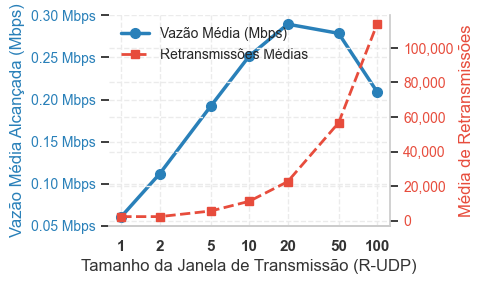

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CONFIGURAÇÕES VISUAIS (Estilo Premium)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

# =========================================================================
# 2. CARREGAMENTO E FILTRAGEM DOS DADOS
# =========================================================================
caminho_csv = '../dados_e_logs/processados/tarefa5_janela.csv'
# Fallback caso o script seja executado a partir do diretório raiz
if not os.path.exists(caminho_csv):
    caminho_csv = 'dados_e_logs/processados/tarefa5_janela.csv'

df = pd.read_csv(caminho_csv)

# Filtrar pelo Cenário B (Perda leve de 10% e latência para avaliar o efeito do timeout)
df_janela_B = df[df['cenario'] == 'B'].copy()

# Ordenar por tamanho da janela para garantir a continuidade da linha
df_janela_B = df_janela_B.sort_values(by='janela')

# =========================================================================
# 3. GERAÇÃO DO GRÁFICO COM EIXO Y DUPLO (TWINX)
# =========================================================================
fig, ax1 = plt.subplots(figsize=(5, 3))

color_vazao = '#2980B9'  # Azul clássico para dados/vazão
color_retx = '#E74C3C'   # Vermelho para perdas/retransmissões

# --- Eixo Esquerdo (Vazão Média em Mbps) ---
ax1.set_xlabel('Tamanho da Janela de Transmissão (R-UDP)', fontsize=12, fontweight='500', color='#333333')
ax1.set_ylabel('Vazão Média Alcançada (Mbps)', color=color_vazao, fontsize=12, fontweight='500')

line1 = ax1.plot(
    df_janela_B['janela'], 
    df_janela_B['vazao_media_mbps'], 
    color=color_vazao, 
    marker='o', 
    markersize=7, 
    linewidth=2.5,
    label='Vazão Média (Mbps)'
)
ax1.tick_params(axis='y', labelcolor=color_vazao, labelsize=10)
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x:.2f} Mbps"))

# --- Eixo Direito (Média de Retransmissões) ---
ax2 = ax1.twinx()  
ax2.set_ylabel('Média de Retransmissões', color=color_retx, fontsize=12, fontweight='500')

line2 = ax2.plot(
    df_janela_B['janela'], 
    df_janela_B['retransmissoes_media'], 
    color=color_retx, 
    marker='s', 
    markersize=6, 
    linestyle='--', 
    linewidth=2,
    label='Retransmissões Médias'
)
ax2.tick_params(axis='y', labelcolor=color_retx, labelsize=10)
# Formatar com separador de milhar no eixo Y2
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
ax2.spines['right'].set_visible(True)  # Torna a borda direita visível para delimitar o eixo duplo

# --- Ajustes Finais de Layout ---
# plt.title('Sensibilidade da Janela R-UDP: Vazão vs Retransmissões\n(Cenário B - Perda de 10% e Latência de 50 ms)', 
#           fontsize=14, fontweight='bold', pad=25, color='#333333')

# Configurar rótulos do Eixo X correspondendo aos tamanhos discretos de janela testados
ax1.set_xticks(df_janela_B['janela'].unique())
ax1.set_xticklabels(df_janela_B['janela'].unique(), fontsize=11, fontweight='600', color='#333333')

# Ajustar escala X para logarítmica (opcional) de modo a espaçar melhor [1, 2, 5, 10, 20, 50, 100]
ax1.set_xscale('log')
ax1.set_xticks(df_janela_B['janela'].unique())
ax1.get_xaxis().set_major_formatter(plt.ScalarFormatter())

# Unificar as legendas de ambos os eixos em um único quadro
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=False, fontsize=10)

plt.tight_layout()

# Salvar figura (PNG de alta resolução e PDF vetorial)
os.makedirs('../relatorio_sbc/figuras', exist_ok=True)
try:
    plt.savefig('../relatorio_sbc/figuras/tarefas/sensibilidade_janela_tarefa5.pdf', dpi=300, bbox_inches='tight')
except Exception:
    os.makedirs('relatorio_sbc/figuras', exist_ok=True)
    plt.savefig('relatorio_sbc/figuras/tarefas/sensibilidade_janela_tarefa5.pdf', dpi=300, bbox_inches='tight')

plt.show()

Sua implementação do R-UDP usou uma janela de tamanho 10, mas será que essa foi a melhor escolha?

### 3. Validação do Simulador (Tarefas 1, 2 e 6)

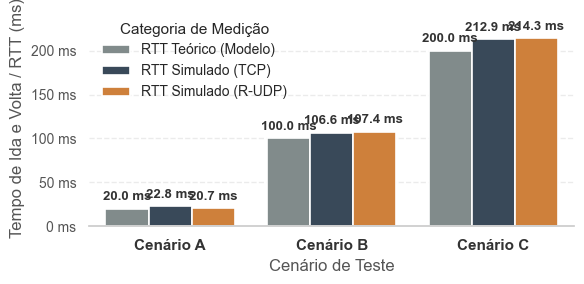

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CONFIGURAÇÕES VISUAIS (Estilo Premium)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

# =========================================================================
# 2. CARREGAMENTO E PREPARAÇÃO DOS DADOS
# =========================================================================
caminho_csv = '../dados_e_logs/processados/tarefa6_rtt.csv'
# Fallback caso o script seja executado a partir do diretório raiz
if not os.path.exists(caminho_csv):
    caminho_csv = 'dados_e_logs/processados/tarefa6_rtt.csv'

df = pd.read_csv(caminho_csv)

# Remodelação lógica para criar 3 barras agrupadas por cenário
dados_plot = []
cenarios = ['A', 'B', 'C']

for cen in cenarios:
    # Obtém RTT Teórico (20ms, 100ms, 200ms)
    rtt_teorico = df[df['cenario'] == cen]['rtt_teorico_ms'].iloc[0]
    
    # Obtém RTT Médio Simulado para cada protocolo
    rtt_tcp = df[(df['cenario'] == cen) & (df['protocolo'] == 'TCP')]['rtt_medio_simulado_ms'].iloc[0]
    rtt_rudp = df[(df['cenario'] == cen) & (df['protocolo'] == 'R-UDP')]['rtt_medio_simulado_ms'].iloc[0]
    
    # Adiciona à lista estruturada
    dados_plot.append({'Cenario': f"Cenário {cen}", 'Tipo': 'RTT Teórico (Modelo)', 'RTT_ms': rtt_teorico})
    dados_plot.append({'Cenario': f"Cenário {cen}", 'Tipo': 'RTT Simulado (TCP)', 'RTT_ms': rtt_tcp})
    dados_plot.append({'Cenario': f"Cenário {cen}", 'Tipo': 'RTT Simulado (R-UDP)', 'RTT_ms': rtt_rudp})

df_plot = pd.DataFrame(dados_plot)

# =========================================================================
# 3. GERAÇÃO DO GRÁFICO DE BARRAS AGRUPADAS
# =========================================================================
plt.figure(figsize=(6, 3))

# Paleta de Cores: Azul para TCP, Laranja para R-UDP e Cinza para o Teórico
cores_validacao = {
    'RTT Teórico (Modelo)': '#7F8C8D',   # Cinza Neutro
    'RTT Simulado (TCP)': '#34495E',     # Azul Escuro
    'RTT Simulado (R-UDP)': '#E67E22'    # Laranja
}

ax = sns.barplot(
    data=df_plot,
    x='Cenario',
    y='RTT_ms',
    hue='Tipo',
    palette=cores_validacao,
    edgecolor='white',
    linewidth=1.2
)

# Adicionar os números exatos sobre cada barra (RTT em ms)
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{altura:.1f} ms', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    fontsize=9.5, fontweight='bold', color='#333333', 
                    xytext=(0, 4), textcoords='offset points')

# Estilização de Eixos e Títulos
# plt.title('Validação do Modelo de Simulação: RTT Teórico vs. RTT Simulado\n(Confirmação Estatística de Atraso e Tempo de Ida e Volta)', 
#           fontsize=14, fontweight='bold', pad=25, color='#333333')
plt.ylabel('Tempo de Ida e Volta / RTT (ms)', fontsize=12, fontweight='500', color='#555555')
plt.xlabel('Cenário de Teste', fontsize=12, fontweight='500', color='#555555')

plt.xticks(fontsize=11, fontweight='600', color='#333333')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)} ms"))
plt.yticks(fontsize=10, color='#555555')

# Configurar legenda elegante sem borda
plt.legend(title='Categoria de Medição', title_fontsize='11', fontsize='10', frameon=False, loc='upper left')

# Ajusta o limite superior do eixo Y para acomodar as anotações
max_val = df_plot['RTT_ms'].max()
plt.ylim(0, max_val * 1.15)

plt.tight_layout()

# Salvar figura (PNG de alta resolução e PDF vetorial)
os.makedirs('../relatorio_sbc/figuras', exist_ok=True)
try:
    plt.savefig('../relatorio_sbc/figuras/tarefas/validacao_simulador_tarefa6.pdf', dpi=300, bbox_inches='tight')
except Exception:
    os.makedirs('relatorio_sbc/figuras', exist_ok=True)
    plt.savefig('relatorio_sbc/figuras/tarefas/validacao_simulador_tarefa6.pdf', dpi=300, bbox_inches='tight')

plt.show()

Todo artigo de simulação precisa de uma seção "O simulador reflete a realidade?".

### 4. Explosão de Overhead: Dados vs Controle (Tarefa 9)

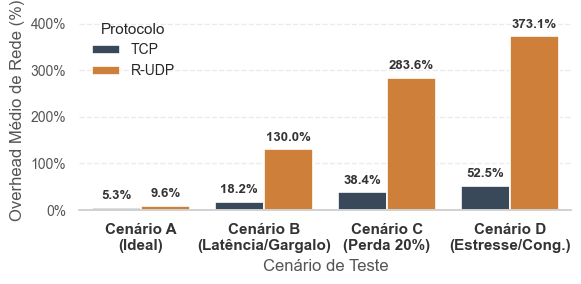

In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CONFIGURAÇÕES VISUAIS (Estilo Premium)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

# =========================================================================
# 2. CARREGAMENTO E PROCESSAMENTO DOS DADOS
# =========================================================================
caminho_csv = '../dados_e_logs/processados/tarefa9_eficiencia.csv'
# Fallback caso o script seja executado a partir do diretório raiz
if not os.path.exists(caminho_csv):
    caminho_csv = 'dados_e_logs/processados/tarefa9_eficiencia.csv'

df = pd.read_csv(caminho_csv)

# Mapeamento amigável dos cenários para exibição
mapeamento_cenarios = {
    'A': 'Cenário A\n(Ideal)',
    'B': 'Cenário B\n(Latência/Gargalo)',
    'C': 'Cenário C\n(Perda 20%)',
    'D_estresse': 'Cenário D\n(Estresse/Cong.)'
}
df['cenario_formatado'] = df['cenario'].map(mapeamento_cenarios)

ordem_cenarios = [
    'Cenário A\n(Ideal)',
    'Cenário B\n(Latência/Gargalo)',
    'Cenário C\n(Perda 20%)',
    'Cenário D\n(Estresse/Cong.)'
]

# Paleta de cores consistente com os demais gráficos
cores_protocolo = {"TCP": "#34495E", "R-UDP": "#E67E22"}

# =========================================================================
# 3. GERAÇÃO DO GRÁFICO DE BARRAS AGRUPADAS
# =========================================================================
plt.figure(figsize=(6, 3))

ax = sns.barplot(
    data=df,
    x='cenario_formatado',
    y='overhead_medio_pct',
    hue='protocolo',
    order=ordem_cenarios,
    palette=cores_protocolo,
    edgecolor='white',
    linewidth=1.2
)

# Adicionar os números exatos sobre cada barra (Porcentagem de Overhead)
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{altura:.1f}%', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    fontsize=9.5, fontweight='bold', color='#333333', 
                    xytext=(0, 4), textcoords='offset points')

# Estilização de Eixos e Títulos
# plt.title('Explosão de Overhead de Rede: Dados de Controle vs. Dados Úteis\n(Frequência Relativa de Overhead sobre o Payload - TCP vs R-UDP)', 
#           fontsize=14, fontweight='bold', pad=25, color='#333333')
plt.ylabel('Overhead Médio de Rede (%)', fontsize=12, fontweight='500', color='#555555')
plt.xlabel('Cenário de Teste', fontsize=12, fontweight='500', color='#555555')

plt.xticks(fontsize=11, fontweight='600', color='#333333')
# Formata o eixo Y para exibir com o símbolo de porcentagem (%)
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)}%"))
plt.yticks(fontsize=10, color='#555555')

# Configurar legenda elegante sem borda
plt.legend(title='Protocolo', title_fontsize='11', fontsize='10', frameon=False, loc='upper left')

# Ajusta o limite superior do eixo Y para acomodar as anotações
max_val = df['overhead_medio_pct'].max()
plt.ylim(0, max_val * 1.15)

plt.tight_layout()

# Salvar figura (PNG de alta resolução e PDF vetorial)
os.makedirs('../relatorio_sbc/figuras', exist_ok=True)
try:
    plt.savefig('../relatorio_sbc/figuras/tarefas/overhead_rede_tarefa9.pdf', dpi=300, bbox_inches='tight')
except Exception:
    os.makedirs('relatorio_sbc/figuras', exist_ok=True)
    plt.savefig('relatorio_sbc/figuras/tarefas/overhead_rede_tarefa9.pdf', dpi=300, bbox_inches='tight')

plt.show()

### 5. Rigor Estatístico: Intervalos de Confiança (Tarefa 10)

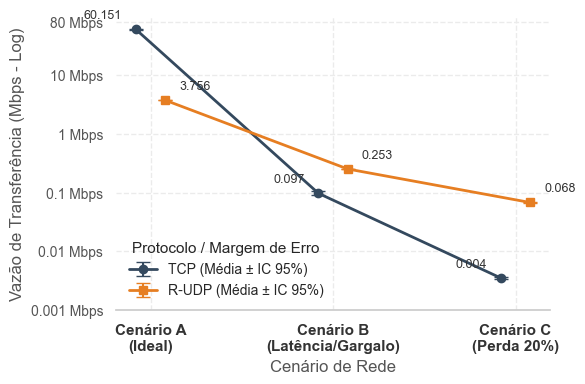

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CONFIGURAÇÕES VISUAIS (Estilo Premium)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

# =========================================================================
# 2. CARREGAMENTO E FILTRAGEM DOS DADOS
# =========================================================================
caminho_csv = '../dados_e_logs/processados/tarefa10_convergencia.csv'
# Fallback caso o script seja executado a partir do diretório raiz
if not os.path.exists(caminho_csv):
    caminho_csv = 'dados_e_logs/processados/tarefa10_convergencia.csv'

df = pd.read_csv(caminho_csv)

# Filtrar para a métrica de vazão em Mbps
df_vazao = df[df['metrica'] == 'vazao_mbps'].copy()

# Garantir a ordenação correta dos cenários (A, B, C)
df_vazao = df_vazao.sort_values(by='cenario')

# Separar os conjuntos por protocolo
df_tcp = df_vazao[df_vazao['protocolo'] == 'TCP'].copy()
df_rudp = df_vazao[df_vazao['protocolo'] == 'R-UDP'].copy()

# =========================================================================
# 3. GERAÇÃO DO GRÁFICO DE PONTOS COM BARRAS DE ERRO (IC 95%)
# =========================================================================
plt.figure(figsize=(6, 4))

cenarios = ['Cenário A\n(Ideal)', 'Cenário B\n(Latência/Gargalo)', 'Cenário C\n(Perda 20%)']
x_pos = np.arange(len(cenarios))
offset = 0.08  # Pequeno deslocamento lateral para evitar sobreposição visual das linhas

# Cores consistentes
cores_protocolo = {"TCP": "#34495E", "R-UDP": "#E67E22"}

# 1. Plot das barras de erro do TCP (Média ± Margem de Erro do IC 95%)
plt.errorbar(
    x_pos - offset, 
    df_tcp['media'], 
    yerr=df_tcp['margem_erro'], 
    fmt='o-',               # Marcador redondo e linha sólida
    color=cores_protocolo['TCP'], 
    linewidth=2, 
    elinewidth=1.5,        # Espessura da linha do erro
    capsize=5,             # Largura das abas terminais do erro
    label='TCP (Média ± IC 95%)'
)

# 2. Plot das barras de erro do R-UDP
plt.errorbar(
    x_pos + offset, 
    df_rudp['media'], 
    yerr=df_rudp['margem_erro'], 
    fmt='s-',               # Marcador quadrado e linha sólida
    color=cores_protocolo['R-UDP'], 
    linewidth=2, 
    elinewidth=1.5, 
    capsize=5, 
    label='R-UDP (Média ± IC 95%)'
)

# 3. Escala Logarítmica e Formatação
plt.yscale('log')

ax = plt.gca()
# Marcadores manuais no eixo Y para facilitar a leitura rápida na escala log
ax.set_yticks([0.001, 0.01, 0.1, 1.0, 10.0, 80.0])
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{x} Mbps" if x < 1 else f"{int(x)} Mbps"))

# Adição de textos com os valores médios exatos em cima dos pontos para maior precisão
for i in range(len(cenarios)):
    val_tcp = df_tcp['media'].iloc[i]
    val_rudp = df_rudp['media'].iloc[i]
    
    # Texto TCP (com leve ajuste de posição)
    ax.annotate(f"{val_tcp:.3f}", (x_pos[i] - offset, val_tcp),
                textcoords="offset points", xytext=(-10, 8), ha='right', 
                fontsize=9, fontweight='500', color='#333333')
    
    # Texto R-UDP
    ax.annotate(f"{val_rudp:.3f}", (x_pos[i] + offset, val_rudp),
                textcoords="offset points", xytext=(10, 8), ha='left', 
                fontsize=9, fontweight='500', color='#333333')

# Estilização de Eixos e Títulos
# plt.title('Rigor Estatístico: Convergência de Vazão por Cenário\n(Média da Vazão com Intervalo de Confiança de 95% - t-Student, N=30)', 
#           fontsize=14, fontweight='bold', pad=25, color='#333333')
plt.ylabel('Vazão de Transferência (Mbps - Log)', fontsize=12, fontweight='500', color='#555555')
plt.xlabel('Cenário de Rede', fontsize=12, fontweight='500', color='#555555')

plt.xticks(x_pos, cenarios, fontsize=11, fontweight='600', color='#333333')
plt.yticks(fontsize=10, color='#555555')

# Configurar legenda elegante sem borda
plt.legend(title='Protocolo / Margem de Erro', title_fontsize='11', fontsize='10', frameon=False, loc='lower left')

plt.tight_layout()

# Salvar figura (PNG de alta resolução e PDF vetorial)
os.makedirs('../relatorio_sbc/figuras', exist_ok=True)
try:
    plt.savefig('../relatorio_sbc/figuras/tarefas/convergencia_estatistica_tarefa10.pdf', dpi=300, bbox_inches='tight')
except Exception:
    os.makedirs('relatorio_sbc/figuras', exist_ok=True)
    plt.savefig('relatorio_sbc/figuras/tarefas/convergencia_estatistica_tarefa10.pdf', dpi=300, bbox_inches='tight')

plt.show()

Você calculou o IC de 95% usando *t-student*. Esse é o "Selo de Qualidade de Mestrado".

### **Tarefa 1: Validação do Modelo de Atraso (Barplot Agrupado)**

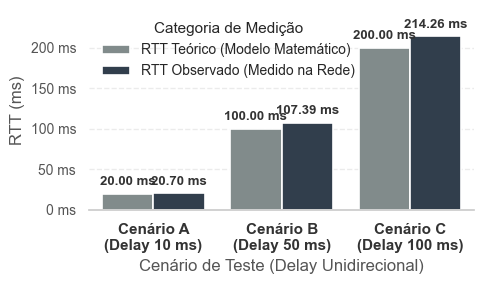

In [56]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CONFIGURAÇÕES VISUAIS (Estilo Premium)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

# =========================================================================
# 2. CARREGAMENTO E FORMATAÇÃO DOS DADOS
# =========================================================================
caminho_csv = '../dados_e_logs/processados/tarefa1_atraso.csv'
# Fallback caso o script seja executado a partir do diretório raiz
if not os.path.exists(caminho_csv):
    caminho_csv = 'dados_e_logs/processados/tarefa1_atraso.csv'

df = pd.read_csv(caminho_csv)

# Remapeamento amigável dos cenários indicando o delay configurado unidirecional
# RTT Teórico = 2 * delay configurado
mapeamento_cenarios = {
    'A': 'Cenário A\n(Delay 10 ms)',
    'B': 'Cenário B\n(Delay 50 ms)',
    'C': 'Cenário C\n(Delay 100 ms)'
}
df['cenario_formatado'] = df['cenario'].map(mapeamento_cenarios)

# "Derrete" o dataframe para colocar as métricas em formato longo (melhor para o seaborn)
df_melt = pd.melt(
    df,
    id_vars=['cenario_formatado'],
    value_vars=['rtt_teorico_ms', 'rtt_medio_observado_ms'],
    var_name='Metrica',
    value_name='RTT_ms'
)

# Renomeia as legendas das métricas
df_melt['Metrica'] = df_melt['Metrica'].map({
    'rtt_teorico_ms': 'RTT Teórico (Modelo Matemático)',
    'rtt_medio_observado_ms': 'RTT Observado (Medido na Rede)'
})

ordem_cenarios = [
    'Cenário A\n(Delay 10 ms)',
    'Cenário B\n(Delay 50 ms)',
    'Cenário C\n(Delay 100 ms)'
]

# =========================================================================
# 3. GERAÇÃO DO GRÁFICO DE BARRAS AGRUPADAS
# =========================================================================
plt.figure(figsize=(5, 3))

# Cores: Cinza neutro para o Teórico, Azul de rede para o Observado
cores_validacao = {
    'RTT Teórico (Modelo Matemático)': '#7F8C8D',   # Cinza
    'RTT Observado (Medido na Rede)': '#2C3E50'     # Azul Marinho Escuro
}

ax = sns.barplot(
    data=df_melt,
    x='cenario_formatado',
    y='RTT_ms',
    hue='Metrica',
    order=ordem_cenarios,
    palette=cores_validacao,
    edgecolor='white',
    linewidth=1.2
)

# Adicionar os valores numéricos exatos em milissegundos sobre cada barra
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{altura:.2f} ms', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    fontsize=9.5, fontweight='bold', color='#333333', 
                    xytext=(0, 4), textcoords='offset points')

# Estilização de Eixos e Títulos
# plt.title('Validação do Modelo de Atraso: RTT Teórico vs. RTT Real Observado\n(Fase 1 - Confirmação da Precisão do Delay Injetado por tc/netem)', 
#           fontsize=14, fontweight='bold', pad=25, color='#333333')
plt.ylabel('RTT (ms)', fontsize=12, fontweight='500', color='#555555')
plt.xlabel('Cenário de Teste (Delay Unidirecional)', fontsize=12, fontweight='500', color='#555555')

plt.xticks(fontsize=11, fontweight='600', color='#333333')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)} ms"))
plt.yticks(fontsize=10, color='#555555')

# Configurar legenda elegante sem borda
plt.legend(title='Categoria de Medição', title_fontsize='11', fontsize='10', frameon=False, loc='upper left')

# Ajusta o limite superior do eixo Y para acomodar as anotações
max_val = df_melt['RTT_ms'].max()
plt.ylim(0, max_val * 1.15)

plt.tight_layout()

# Salvar figura (PNG de alta resolução e PDF vetorial)
os.makedirs('../relatorio_sbc/figuras', exist_ok=True)
try:
    plt.savefig('../relatorio_sbc/figuras/tarefas/validacao_atraso_tarefa1.pdf', dpi=300, bbox_inches='tight')
except Exception:
    os.makedirs('relatorio_sbc/figuras', exist_ok=True)
    plt.savefig('relatorio_sbc/figuras/tarefas/validacao_atraso_tarefa1.pdf', dpi=300, bbox_inches='tight')

plt.show()

* **Objetivo:** Provar que o atraso inserido no SimPy (variável no `env.timeout`) se reflete no RTT real.
* **Visual:** Barras lado a lado comparando o "RTT Teórico" (2x o delay) com o "RTT Simulado". O esperado é que as barras sejam quase da mesma altura, provando a precisão do simulador.

### Tarefa 2: Validação da Perda de Bernoulli (Gráfico de Linha/Dispersão)

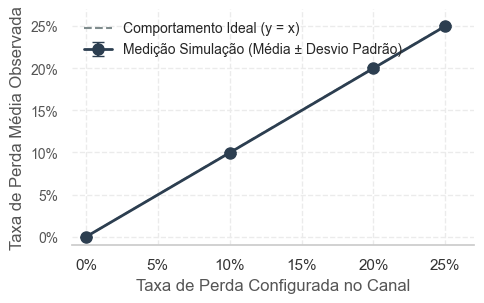

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CONFIGURAÇÕES VISUAIS (Estilo Premium)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

# =========================================================================
# 2. CARREGAMENTO E PROCESSAMENTO DOS DADOS
# =========================================================================
caminho_csv = '../dados_e_logs/processados/tarefa2_perda.csv'
# Fallback caso o script seja executado a partir do diretório raiz
if not os.path.exists(caminho_csv):
    caminho_csv = 'dados_e_logs/processados/tarefa2_perda.csv'

df = pd.read_csv(caminho_csv)

# Conversão de escala decimal para porcentagem (%)
df['configurada_pct'] = df['taxa_perda_configurada'] * 100
df['observada_pct'] = df['taxa_perda_media_observada'] * 100
df['desvio_pct'] = df['taxa_perda_desvio'] * 100

# =========================================================================
# 3. GERAÇÃO DO GRÁFICO DE DISPERSÃO E LINHA DE REFERÊNCIA
# =========================================================================
plt.figure(figsize=(5, 3.2))

# 1. Linha diagonal ideal y = x (Comportamento Teórico Esperado)
x_diag = np.linspace(0, 25, 100)
plt.plot(x_diag, x_diag, color='#7F8C8D', linestyle='--', linewidth=1.5, label='Comportamento Ideal (y = x)')

# 2. Pontos medidos da simulação com barras de desvio padrão
plt.errorbar(
    df['configurada_pct'], 
    df['observada_pct'], 
    yerr=df['desvio_pct'], 
    fmt='o-', 
    color='#2C3E50',          # Azul Escuro
    linewidth=2, 
    elinewidth=1.5, 
    capsize=4, 
    markersize=8, 
    label='Medição Simulação (Média ± Desvio Padrão)'
)

# Estilização de Eixos e Títulos
# plt.title('Validação da Perda Estocástica de Bernoulli no Simulador\n(Taxa de Perda Configurada vs. Taxa de Perda Real Observada na Rede)', 
#           fontsize=13, fontweight='bold', pad=25, color='#333333')
plt.xlabel('Taxa de Perda Configurada no Canal', fontsize=12, fontweight='500', color='#555555')
plt.ylabel('Taxa de Perda Média Observada', fontsize=12, fontweight='500', color='#555555')

# Forçar formatação de porcentagem nos ticks dos eixos X e Y
ax = plt.gca()
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)}%"))
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)}%"))

plt.xticks(fontsize=11, color='#333333')
plt.yticks(fontsize=10, color='#555555')

# Configurar legenda elegante sem borda
plt.legend(frameon=False, fontsize=10, loc='upper left')

# Definir limites idênticos nos eixos para a diagonal ficar no ângulo correto de 45°
plt.xlim(-1, 27)
plt.ylim(-1, 27)

plt.tight_layout()

# Salvar figura (PNG de alta resolução e PDF vetorial)
os.makedirs('../relatorio_sbc/figuras', exist_ok=True)
try:
    plt.savefig('../relatorio_sbc/figuras/tarefas/validacao_perda_tarefa2.pdf', dpi=300, bbox_inches='tight')
except Exception:
    os.makedirs('relatorio_sbc/figuras', exist_ok=True)
    plt.savefig('relatorio_sbc/figuras/tarefas/validacao_perda_tarefa2.pdf', dpi=300, bbox_inches='tight')

plt.show()

* **Objetivo:** Provar que a sua função de perda (`random.random() < loss_rate`) obedece à distribuição estocástica ao longo de dezenas de execuções.
* **Visual:** Eixo X = Taxa de Perda Configurada (0%, 10%, 20%, 25%). Eixo Y = Taxa de Perda Observada. Uma linha diagonal perfeita (y=x) indica que o simulador é matematicamente robusto.

### Tarefa 3: O Impacto dos Timeouts (Barplot)

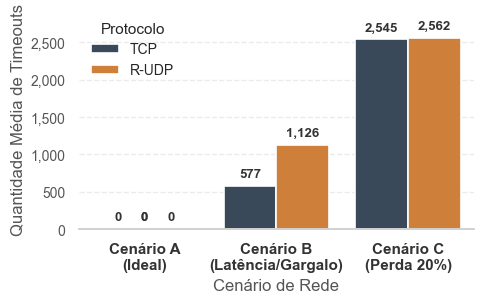

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CONFIGURAÇÕES VISUAIS (Estilo Premium)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

# =========================================================================
# 2. CARREGAMENTO E MAPEAMENTO DOS DADOS
# =========================================================================
caminho_csv = '../dados_e_logs/processados/tarefa3_timeout.csv'
# Fallback caso o script seja executado a partir do diretório raiz
if not os.path.exists(caminho_csv):
    caminho_csv = 'dados_e_logs/processados/tarefa3_timeout.csv'

df = pd.read_csv(caminho_csv)

# Mapeamento amigável dos cenários para exibição
mapeamento_cenarios = {
    'A': 'Cenário A\n(Ideal)',
    'B': 'Cenário B\n(Latência/Gargalo)',
    'C': 'Cenário C\n(Perda 20%)'
}
df['cenario_formatado'] = df['cenario'].map(mapeamento_cenarios)

ordem_cenarios = [
    'Cenário A\n(Ideal)',
    'Cenário B\n(Latência/Gargalo)',
    'Cenário C\n(Perda 20%)'
]

# Paleta de cores consistente com os demais gráficos
cores_protocolo = {"TCP": "#34495E", "R-UDP": "#E67E22"}

# =========================================================================
# 3. GERAÇÃO DO GRÁFICO DE BARRAS AGRUPADAS (TIMEOUTS)
# =========================================================================
plt.figure(figsize=(5, 3.2))

ax = sns.barplot(
    data=df,
    x='cenario_formatado',
    y='timeouts_media',
    hue='protocolo',
    order=ordem_cenarios,
    palette=cores_protocolo,
    edgecolor='white',
    linewidth=1.2
)

# Adicionar os números exatos sobre cada barra (Média de Timeouts)
for p in ax.patches:
    altura = p.get_height()
    if altura > 0:
        ax.annotate(f'{int(round(altura)):,}', 
                    (p.get_x() + p.get_width() / 2., altura), 
                    ha='center', va='bottom', 
                    fontsize=9.5, fontweight='bold', color='#333333', 
                    xytext=(0, 4), textcoords='offset points')
    elif altura == 0:
        ax.annotate('0', 
                    (p.get_x() + p.get_width() / 2., 0), 
                    ha='center', va='bottom', 
                    fontsize=9.5, fontweight='bold', color='#333333', 
                    xytext=(0, 4), textcoords='offset points')

# Estilização de Eixos e Títulos
# plt.title('Estouro de Temporizadores: Ocorrência Média de Timeouts\n(Análise Comparativa de Recuperação de Perdas na Rede - TCP vs R-UDP)', 
#           fontsize=14, fontweight='bold', pad=25, color='#333333')
plt.ylabel('Quantidade Média de Timeouts', fontsize=12, fontweight='500', color='#555555')
plt.xlabel('Cenário de Rede', fontsize=12, fontweight='500', color='#555555')

plt.xticks(fontsize=11, fontweight='600', color='#333333')
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
plt.yticks(fontsize=10, color='#555555')

# Configurar legenda elegante sem borda
plt.legend(title='Protocolo', title_fontsize='11', fontsize='10', frameon=False, loc='upper left')

# Ajusta o limite superior do eixo Y para acomodar as anotações
max_val = df['timeouts_media'].max()
plt.ylim(0, max_val * 1.15)

plt.tight_layout()

# Salvar figura na pasta figuras/tarefas conforme solicitado
pasta_saida = '../relatorio_sbc/figuras/tarefas/'
os.makedirs(pasta_saida, exist_ok=True)

caminho_pdf = os.path.join(pasta_saida, 'tarefa3_timeout.pdf')

try:
    plt.savefig(caminho_pdf, dpi=300, bbox_inches='tight')
except Exception:
    # Fallback local caso o Jupyter não acesse a pasta acima
    fallback_path = 'relatorio_sbc/figuras/tarefas/'
    os.makedirs(fallback_path, exist_ok=True)
    plt.savefig(os.path.join(fallback_path, 'tarefa3_timeout.pdf'), dpi=300, bbox_inches='tight')

plt.show()

* **Objetivo:** Mostrar a relação direta entre perdas na rede e o estouro de temporizadores.
* **Visual:** Barras mostrando a quantidade média de `timeouts` por cenário. O R-UDP, por não ter *Fast Retransmit* como o TCP, dependerá exclusivamente de timeouts para recuperar perdas, o que ficará evidente aqui.

### Tarefa 7: Sensibilidade ao Jitter (Lineplot)

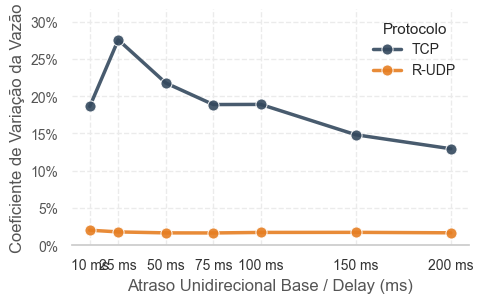

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CONFIGURAÇÕES VISUAIS (Estilo Premium)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

# =========================================================================
# 2. CARREGAMENTO E ORDENAÇÃO DOS DADOS
# =========================================================================
caminho_csv = '../dados_e_logs/processados/tarefa7_jitter.csv'
# Fallback caso o script seja executado a partir do diretório raiz
if not os.path.exists(caminho_csv):
    caminho_csv = 'dados_e_logs/processados/tarefa7_jitter.csv'

df = pd.read_csv(caminho_csv)

# Ordenação pelo atraso base para garantir linhas contínuas
df = df.sort_values(by='delay_ms')

# =========================================================================
# 3. GERAÇÃO DO GRÁFICO DE LINHAS (SENSIVILIDADE AO JITTER)
# =========================================================================
plt.figure(figsize=(5, 3.2))

# Paleta de cores consistente com os demais gráficos do projeto
cores_protocolo = {"TCP": "#34495E", "R-UDP": "#E67E22"}

# Plotagem usando o lineplot do Seaborn com marcadores e espessuras customizadas
ax = sns.lineplot(
    data=df,
    x='delay_ms',
    y='coef_variacao_vazao_pct',
    hue='protocolo',
    palette=cores_protocolo,
    marker='o',
    markersize=8,
    linewidth=2.5,
    alpha=0.9
)

# Estilização de Eixos e Títulos
# plt.title('Sensibilidade ao Jitter: Instabilidade da Vazão vs. Atraso Base\n(Coeficiente de Variação da Vazão sob Atraso Variável - Jitter = 10% do Delay)', 
#           fontsize=13, fontweight='bold', pad=25, color='#333333')
plt.xlabel('Atraso Unidirecional Base / Delay (ms)', fontsize=12, fontweight='500', color='#555555')
plt.ylabel('Coeficiente de Variação da Vazão', fontsize=12, fontweight='500', color='#555555')

# Configurar as marcações do eixo X com os delays reais amostrados
ax.set_xticks(df['delay_ms'].unique())
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)} ms"))
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)}%"))

plt.xticks(fontsize=10, color='#333333')
plt.yticks(fontsize=10, color='#555555')

# Configurar legenda elegante sem borda
plt.legend(title='Protocolo', title_fontsize='11', fontsize='10', frameon=False, loc='upper right')

# Respiro vertical do eixo Y
plt.ylim(0, df['coef_variacao_vazao_pct'].max() * 1.15)

plt.tight_layout()

# Salvar figura na pasta figuras/tarefas conforme solicitado
pasta_saida = '../relatorio_sbc/figuras/tarefas/'
os.makedirs(pasta_saida, exist_ok=True)

caminho_pdf = os.path.join(pasta_saida, 'tarefa7_jitter.pdf')

try:
    plt.savefig(caminho_pdf, dpi=300, bbox_inches='tight')
except Exception:
    # Fallback local caso o Jupyter não acesse a pasta acima
    fallback_path = 'relatorio_sbc/figuras/tarefas/'
    os.makedirs(fallback_path, exist_ok=True)
    plt.savefig(os.path.join(fallback_path, 'tarefa7_jitter.pdf'), dpi=300, bbox_inches='tight')

plt.show()

* **Objetivo:** O Jitter (variação do atraso) afeta a estabilidade da vazão. Quanto maior o Jitter, mais os pacotes chegam fora de cadência.
* **Visual:** Eixo X = Atraso Base (que dita o Jitter). Eixo Y = Coeficiente de Variação da Vazão (%). Mostra como a entrega de dados perde a constância (aumenta a variância) quando a rede fica instável.

### Tarefa 8: O Cenário de Estresse Extremo (Gráfico de Barras Duplo)

C:\Users\Carlos Vale\AppData\Local\Temp\ipykernel_5316\3138068711.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot1 = sns.barplot(
C:\Users\Carlos Vale\AppData\Local\Temp\ipykernel_5316\3138068711.py:66: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['TCP', 'R-UDP'], fontsize=11, fontweight='600')
C:\Users\Carlos Vale\AppData\Local\Temp\ipykernel_5316\3138068711.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot2 = sns.barplot(
C:\Users\Carlos Vale\AppData\Local\Temp\ipykernel_5316\3138068711.py:96: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after 

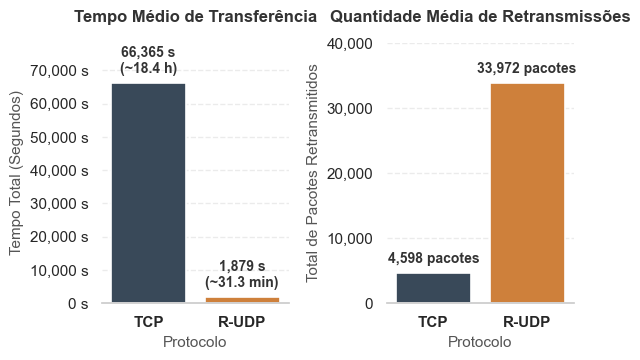

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# =========================================================================
# 1. CONFIGURAÇÕES VISUAIS (Estilo Premium)
# =========================================================================
sns.set_theme(style="whitegrid", rc={
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "grid.color": "#ebebeb",
    "grid.linestyle": "--"
})

# =========================================================================
# 2. CARREGAMENTO DOS DADOS
# =========================================================================
caminho_csv = '../dados_e_logs/processados/tarefa8_estresse.csv'
# Fallback caso o script seja executado a partir do diretório raiz
if not os.path.exists(caminho_csv):
    caminho_csv = 'dados_e_logs/processados/tarefa8_estresse.csv'

df = pd.read_csv(caminho_csv)

# Paleta de cores consistente
cores_protocolo = {"TCP": "#34495E", "R-UDP": "#E67E22"}

# =========================================================================
# 3. GERAÇÃO DO PAINEL DE COMPARATIVO DE ESTRESSE EXTREMO
# =========================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))

# --- Subplot 1 (Esquerda): Tempo Médio de Transferência ---
barplot1 = sns.barplot(
    data=df,
    x='protocolo',
    y='tempo_medio_s',
    palette=cores_protocolo,
    edgecolor='white',
    linewidth=1.2,
    ax=ax1
)

# Adicionar rótulos detalhados acima das barras de tempo (com conversão em horas/minutos)
for p in ax1.patches:
    tempo_s = p.get_height()
    if tempo_s > 3600:
        horas = tempo_s / 3600
        texto = f"{int(round(tempo_s)):,} s\n(~{horas:.1f} h)"
    else:
        minutos = tempo_s / 60
        texto = f"{int(round(tempo_s)):,} s\n(~{minutos:.1f} min)"
        
    ax1.annotate(texto, 
                (p.get_x() + p.get_width() / 2., tempo_s), 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='#333333', 
                xytext=(0, 5), textcoords='offset points')

ax1.set_title('Tempo Médio de Transferência', fontsize=12, fontweight='bold', pad=15, color='#333333')
ax1.set_ylabel('Tempo Total (Segundos)', fontsize=11, color='#555555')
ax1.set_xlabel('Protocolo', fontsize=11, color='#555555')
ax1.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,} s"))
ax1.set_xticklabels(['TCP', 'R-UDP'], fontsize=11, fontweight='600')

# Ajusta escala Y do primeiro plot para dar espaço aos rótulos
ax1.set_ylim(0, df['tempo_medio_s'].max() * 1.18)


# --- Subplot 2 (Direita): Total de Retransmissões ---
barplot2 = sns.barplot(
    data=df,
    x='protocolo',
    y='retransmissoes_media',
    palette=cores_protocolo,
    edgecolor='white',
    linewidth=1.2,
    ax=ax2
)

# Adicionar rótulos numéricos acima das barras de retransmissões
for p in ax2.patches:
    retx = p.get_height()
    ax2.annotate(f"{int(round(retx)):,} pacotes", 
                (p.get_x() + p.get_width() / 2., retx), 
                ha='center', va='bottom', 
                fontsize=10, fontweight='bold', color='#333333', 
                xytext=(0, 5), textcoords='offset points')

ax2.set_title('Quantidade Média de Retransmissões', fontsize=12, fontweight='bold', pad=15, color='#333333')
ax2.set_ylabel('Total de Pacotes Retransmitidos', fontsize=11, color='#555555')
ax2.set_xlabel('Protocolo', fontsize=11, color='#555555')
ax2.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x):,}"))
ax2.set_xticklabels(['TCP', 'R-UDP'], fontsize=11, fontweight='600')

# Ajusta escala Y do segundo plot para dar espaço aos rótulos
ax2.set_ylim(0, df['retransmissoes_media'].max() * 1.18)


# --- Título Geral do Painel ---
# plt.suptitle('Tarefa 8 - Comportamento em Limite de Estresse Extremo\n(Comparativo sob Perda de 25% e Latência RTT de 250 ms)', 
#              fontsize=14, fontweight='bold', color='#2C3E50', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.94])

# Salvar figura na pasta figuras/tarefas conforme solicitado
pasta_saida = '../relatorio_sbc/figuras/tarefas/'
os.makedirs(pasta_saida, exist_ok=True)

caminho_pdf = os.path.join(pasta_saida, 'tarefa8_estresse.pdf')

try:
    plt.savefig(caminho_pdf, dpi=300, bbox_inches='tight')
except Exception:
    # Fallback local caso o Jupyter não acesse a pasta acima
    fallback_path = 'relatorio_sbc/figuras/tarefas/'
    os.makedirs(fallback_path, exist_ok=True)
    plt.savefig(os.path.join(fallback_path, 'tarefa8_estresse.pdf'), dpi=300, bbox_inches='tight')

plt.show()

* **Objetivo:** Resumir a Tarefa 8, que leva a rede ao colapso (25% de perda e 125ms de delay).
* **Visual:** Um comparativo direto entre TCP e R-UDP mostrando o "Tempo Total" vs "Retransmissões", evidenciando o comportamento de cada protocolo na pior situação possível.